Chapter 26
# 比较六种插值方法
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
# 生成随数据
np.random.seed(8) # 种子
x = np.linspace(0, 10, 10) # 点
y = np.random.rand(10) * 10 # 10个数据；生成 10 个 [0, 10) 范围内的随机数作为 y 值。
x_fine = np.linspace(0, 10, 1001) # 10/1000=0.01

In [3]:
print(x)
print(y)

[ 0.          1.11111111  2.22222222  3.33333333  4.44444444  5.55555556
  6.66666667  7.77777778  8.88888889 10.        ]
[8.73429403 9.68540663 8.6919454  5.30855692 2.32728328 0.11398804
 4.30468818 4.0235136  5.22674671 4.78391796]


sharex='col'指定每一列子图将共享相同的 x 轴，

而 sharey='row'指定每一行子图将共享相
同的 y 轴。这样设置可以使得网格中的子图在 x 轴和 。y 轴方向上有一致的刻度和范围

调用 SciPy 库中的 interp1d 函数来进行一维插值。其中，x 这是一个一维数组或列表，表示
原始数据点的横坐标，即自变量。

y 也是一个一维数组或列表，表示原始数据点的纵坐标，即因变量。

b
中的 flatten() 多维数组转换为一维数组。在这里，函数被应用于"axes"轴对象，将二维的
子图网格数组转换成了一维数组。

c
列表列出 6 种插值方法。

d
调用 SciPy 库中的 interp1d 函数来进行一维插值。其中，x 这是一个一维数组或列表，表示
原始数据点的横坐标，即自变量。y 也是一个一维数组或列表，表示原始数据点的纵坐标，即因变量。

参数 kind 用于指定插值方法。其中，'linear' 为线性插值。在两个相邻数据点之间进行线性插
值，即使用直线来连接两个数据点。如图 7 (a) 所示，多点线性插值结果一般为折线。
'quadratic' 是二次插值，相邻点之间通过二次函数连接。如图 7 (b) 所示，二次插值产生的曲线
较为平滑。


'cubic' 是三次插值，相邻点之间通过三次次函数连接。如图 7 (c) 所示，三次插值产生的曲
线非常平滑，能够更好地逼近数据点之间的曲线。

'nearest' 代表最近邻插值。如图 7 (d) 所示，'nearest'使用与插值点最近的数据点的值作
为插值结果。

'previous' 代表前向插值。如图 7 (e) 所示，使用插值点之前的数据点的值作为插值结果。

'next' 代表后向插值。如图 7 (f) 所示，使用插值点之后的数据点的值作为插值结果

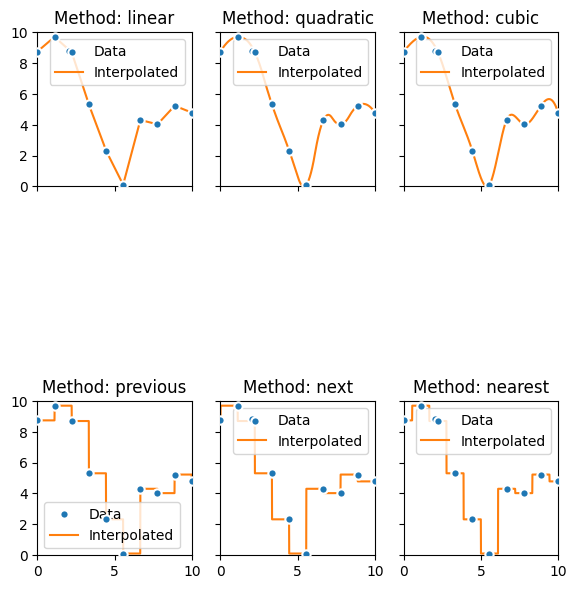

In [4]:
# 创建一个图形对象，包含六个子图
fig, axes = plt.subplots(2, 3, figsize=(6, 9),
                         sharex = 'col',
                         sharey = 'row')
axes = axes.flatten() # 展为一维数组

# 六种插值方法
methods = ['linear','quadratic','cubic',
           'previous','next','nearest']

for i, method in enumerate(methods): #索引；数据

    # 创建 interp1d 对象
    f = interp1d(x, y, kind=method) #x,y原始数据；根据原始数据进行差值

    # 生成插值后的新数据点
    y_fine = f(x_fine) # 生成y值

    # 绘制子图
    axes[i].plot(x, y, 'o', label='Data',
                 markeredgewidth=1.5,
                 markeredgecolor = 'w',
                 zorder = 100)
    # 原始数据
    axes[i].plot(x_fine,y_fine,label='Interpolated') # 插值的图像
    axes[i].set_title(f'Method: {method}') #标题
    axes[i].legend() #图例
    axes[i].set_xlim(0, 10)  #范围
    axes[i].set_ylim(0, 10)
    axes[i].set_aspect('equal', adjustable='box')
plt.tight_layout()
# fig.savefig('不同插值方法.svg', format='svg')

##这些蓝点；就是原始数据；橙线就是插值